In [19]:
config = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 45,
    "group_num": 3,
    "num_cranes": 5, 
    "group_placement": "random",
    "seed": 4307,
    "time_penalty_coef": 0.002,
    "env": "SPGE-MC",
}

In [20]:
config = {
    "vessel_shape": (3,5,3),
    "yard_shape": (3,5,3),
    "num_containers": 200,
    "group_num": 3,
    "num_cranes": 3, 
    "group_placement": "random",
    "seed": 4307,
    "time_penalty_coef": 0.002,
    "env": "SPAEC",
}

In [22]:
from envs.stowage_crane_gym import MultiCraneStowageEnv
env = MultiCraneStowageEnv(config=config, render_mode="rgb_array")
obs, info = env.reset()

In [ ]:
env.time_arr

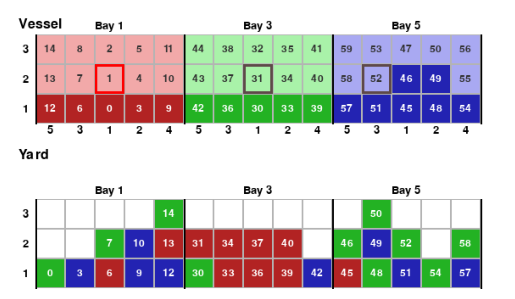

In [73]:
import matplotlib.pyplot as plt

# Get the RGB array
rgb_array = env.render()

# Display the image
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

In [72]:
obs, _,terminated,_,info = env.step(160)
print(info["cranes"]["busy_until"]-info["current_time"])
print(info["total_shifters"])
print(env.current_vessel_slots)
print(terminated)

[ 0 24 13]
0
[1, 31, 52]
False


In [74]:
import numpy as np
for a in list(np.arange(env.action_space.n)[env.action_masks()]):
    print(a, env._decode_action(a))

18 (6, 0)
39 (13, 0)
93 (31, 0)
99 (33, 0)
102 (34, 0)
108 (36, 0)
111 (37, 0)
117 (39, 0)
120 (40, 0)
135 (45, 0)


In [5]:
from envs.stowage_crane_gym import MultiCraneStowageEnv
from sb3_contrib import MaskablePPO
from algorithms.DQN import MaskableDQN
from algorithms.A2C import MaskableA2C
from algorithms.TRPO import MaskableTRPO
from algorithms.QRDQN import MaskableQRDQN
from sb3_contrib.common.maskable.utils import get_action_masks
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3 import PPO
import numpy as np


class TensorboardCallback(BaseCallback):
    """
    Custom callback for plotting additional values in tensorboard.
    """

    def __init__(self, verbose=0):
        self.is_tb_set = False
        super(TensorboardCallback, self).__init__(verbose)

    def _on_step(self) -> bool:
        if self.num_timesteps % 190 == 0:
            # Log to tensorboard

            self.logger.record("metrics/mean_reward", np.mean(self.locals["rewards"]))
            # print(len(self.locals['infos'][0]['action_sequence']))
            total_shifters_lst = []
            current_time_lst = []
            for i in range(len(self.locals["infos"])):
                total_shifters_lst.append(self.locals["infos"][i].get("total_shifters"))
                current_time_lst.append(self.locals["infos"][i].get("current_time"))
            total_shifters = np.mean(total_shifters_lst)
            current_time = np.mean(current_time_lst)
            self.logger.record("metrics/total_shifters", total_shifters)
            self.logger.record("metrics/current_time", current_time)
            self.logger.dump(self.num_timesteps)
        return True

env = MultiCraneStowageEnv(config=config)
obs, info = env.reset()

model = MaskableQRDQN("MlpPolicy", env, verbose=1, gamma=0.4)
model.learn(10000, callback=TensorboardCallback(), log_interval=4)
# env.reset()
# model = MaskablePPO("MlpPolicy", env, gamma=0.4, verbose=1,tensorboard_log="./multi_cranes/", n_steps=2000)
# model.learn(100,callback=TensorboardCallback(),tb_log_name="PPO_100c_3g_5cr")

Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


KeyboardInterrupt: 

In [6]:
from wandb.integration.sb3 import WandbCallback
from envs.stowage_aec import StowageAEC
from sb3_contrib.common.maskable.callbacks import MaskableEvalCallback
import wandb
import gymnasium as gym
class TestCallback(WandbCallback):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

    def _on_step(self) -> bool:
        # Call the parent class's method to log the metrics
        super()._on_step()
        if self.num_timesteps % 500 == 0 or self.num_timesteps == 1:
            # Evaluate the policy
            rew_lst = []
            total_shifters_lst = []
            current_time_lst = []
            ep_len_lst = []
            for i in range(5):
                env = MultiCraneStowageEnv(config=config)
                ep_len = 0
                # env = StowageAEC(config)
                obs, info = env.reset()
                # rewards = []
                total_reward = 0
                while True:
                    action, _ = self.model.predict(obs, deterministic=True, action_masks=np.expand_dims(env.action_masks(), axis=0)) # Used for MaskableQRDQN
                    # action, _ = self.model.predict(obs, action_masks=env.action_masks())
                    obs, reward, terminated, truncated, info = env.step(action)
                    if reward == -100:
                        print("Invalid action taken",action, np.where(env.action_masks()),ep_len)
                    # rewards.append(reward)
                    total_reward += reward
                    ep_len += 1
                    if terminated or truncated:
                        total_shifters = info.get("total_shifters")
                        current_time = info.get("current_time")
                        break
                # mean_r = np.sum(rewards)
                rew_lst.append(total_reward)
                total_shifters_lst.append(total_shifters)
                current_time_lst.append(current_time)
                ep_len_lst.append(ep_len)
            # Log to tensorboard
            self.logger.record("eval/mean_reward", np.mean(rew_lst))
            self.logger.record("eval/total_shifters", np.mean(total_shifters_lst))
            self.logger.record("eval/current_time", np.mean(current_time_lst))
            self.logger.record("eval/ep_len", np.mean(ep_len_lst))
            self.logger.dump(self.num_timesteps)
        return True
# class TrialEvalCallback(MaskableEvalCallback, WandbCallback):
#     """Callback used for evaluating and reporting a trial."""

#     def __init__(
#         self,
#         eval_env: gym.Env,
#         n_eval_episodes: int = 5,
#         eval_freq: int = 500,
#         deterministic: bool = True,
#         verbose: int = 0,
#     ):
#         MaskableEvalCallback.__init__(
#             self,
#             eval_env=eval_env,
#             n_eval_episodes=n_eval_episodes,
#             eval_freq=eval_freq,
#             deterministic=deterministic,
#             verbose=verbose,
#         )
#         WandbCallback.__init__(self)

#     def _on_step(self) -> bool:
#         WandbCallback._on_step(self)
#         MaskableEvalCallback._on_step(self)
#         return True

In [7]:
from sb3_contrib import MaskablePPO
from envs.stowage_aec import StowageAEC
from algorithms.DQN import MaskableDQN
from algorithms.A2C import MaskableA2C
from algorithms.TRPO import MaskableTRPO
from algorithms.QRDQN import MaskableQRDQN
from wandb.integration.sb3 import WandbCallback
from sb3_contrib import TRPO
import numpy as np
import wandb
for i in range(1):
    env = MultiCraneStowageEnv(config=config)
    # env = StowageAEC(config)
    obs, info = env.reset()
    run = wandb.init(
        project="sb3",
        config=config,
        sync_tensorboard=True,  # auto-upload sb3's tensorboard metrics
        # monitor_gym=True,  # auto-upload the videos of agents playing the game
        # save_code=True,  # optional
    )
    model = MaskableQRDQN("MlpPolicy", env, verbose=1, tensorboard_log=f"runs/{run.id}", learning_rate=0.0004)
    # model.learn(total_timesteps=100000, callback=TrialEvalCallback(eval_env=MultiCraneStowageEnv(config=config)))
    model.learn(total_timesteps=100000, callback=TestCallback())
    run.finish()

wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.
wandb: Currently logged in as: yunqihuang (alexisloadmaster-loadmaster-ai). Use `wandb login --relogin` to force relogin


Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Logging to runs/8aj502sn/QRDQN_1
--------------------------------
| eval/             |          |
|    current_time   | 1.26e+03 |
|    ep_len         | 45       |
|    mean_reward    | -25.8    |
|    total_shifters | 22       |
--------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 45       |
|    ep_rew_mean      | -25.9    |
|    exploration_rate | 0.644    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 275      |
|    time_elapsed     | 0        |
|    total_timesteps  | 180      |
| train/              |          |
|    learning_rate    | 0.0004   |
|    loss             | 182      |
|    n_updates        | 19       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 45       |
|    ep_rew

eval/current_time,▃▁▃▃▃▃▃▃█▃▃▃▃▃▃▆▃▃▃▃▃▃▃▃▃▆▆▃▆▃▆▃▃▃▃▃▃▃▃▃
eval/ep_len,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/mean_reward,▁████▇█████████████▇▇██▇██████▇████▇████
eval/total_shifters,█▁▁▁▁▂▁▁▁▁▁▁▂▁▁▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▂▁
global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇█████
rollout/ep_len_mean,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
rollout/ep_rew_mean,▁▂▂▂▂▂▂▁▃▃▅▅▂▃▃▄▅▆▆▆▆▆██▇▂▃▂▂▃▂▃▂▂▅▃▃▃▁▁
rollout/exploration_rate,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
time/fps,▁██▇▆▅▆▆▆▇▆▅▄▅▅▄▄▄▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇
train/learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/loss,█▅▄▃▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁


In [ ]:
obs, _ = env.reset()
while True:
    action, _ = model.predict(obs, action_masks=get_action_masks(env))
    obs, reward, terminated, truncated, info = env.step(action)
    if terminated or truncated:
        break